SECTION 1
Setup

(Import libraries and configure environment)

In [ ]:
import pandas as pd
import numpy as np

from tqdm import tqdm

from collections import defaultdict

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

SECTION 2
Data Loading

(Load Netflix interactions with timestamps)

Load user-movie interactions while preserving temporal information for future-aware evaluation.

In [ ]:
MAX_ROWS = 2_000_000

In [ ]:
data = []

movie_id = None

rows_loaded = 0

with open(
    "combined_data_1.txt",
    "r"
) as f:

    for line in tqdm(f):

        line = line.strip()

        if line.endswith(":"):

            movie_id = int(
                line[:-1]
            )

        else:

            user_id, rating, date = (
                line.split(",")
            )

            data.append([
                int(user_id),
                movie_id,
                int(rating),
                pd.to_datetime(date)
            ])

            rows_loaded += 1

            if rows_loaded >= MAX_ROWS:
                break

2000360it [16:56, 1968.64it/s]


In [ ]:
ratings_df = pd.DataFrame(
    data,
    columns=[
        "user_id",
        "movie_id",
        "rating",
        "date"
    ]
)

ratings_df.head()

,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [ ]:
ratings_df.shape

(2000000, 4)

Observation - A temporally ordered subset of Netflix interactions has been prepared for model development.

SECTION 3
Temporal Split

(Train on past interactions and test on future interactions)

How well can recommendation models predict future user ratings?

In [ ]:
ratings_df = ratings_df.sort_values(
    "date"
)

In [ ]:
split_idx = int(
    len(ratings_df) * 0.8
)

In [ ]:
train_df = ratings_df.iloc[
    :split_idx
].copy()

test_df = ratings_df.iloc[
    split_idx:
].copy()

In [ ]:
print(
    "Train Shape:",
    train_df.shape
)

print(
    "Test Shape:",
    test_df.shape
)

Train Shape: (1600000, 4)
Test Shape: (400000, 4)


In [ ]:
print(
    "Train Start:",
    train_df["date"].min()
)

print(
    "Train End:",
    train_df["date"].max()
)

print()

print(
    "Test Start:",
    test_df["date"].min()
)

print(
    "Test End:",
    test_df["date"].max()
)

Train Start: 1999-12-09 00:00:00
Train End: 2005-07-28 00:00:00

Test Start: 2005-07-28 00:00:00
Test End: 2005-12-31 00:00:00


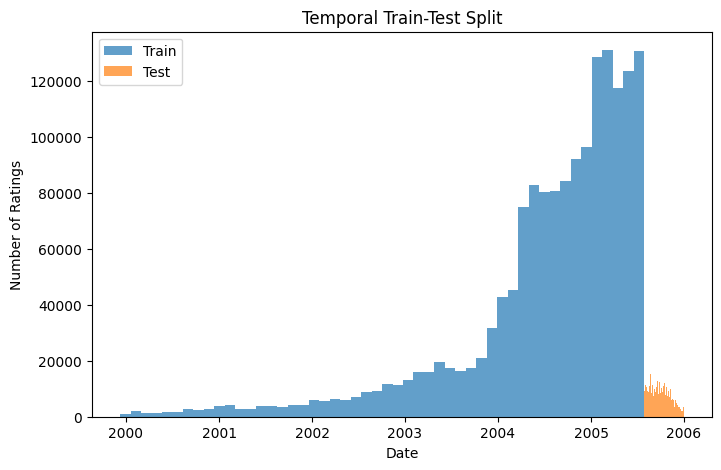

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    train_df["date"],
    bins=50,
    alpha=0.7,
    label="Train"
)

plt.hist(
    test_df["date"],
    bins=50,
    alpha=0.7,
    label="Test"
)

plt.title(
    "Temporal Train-Test Split"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Number of Ratings"
)

plt.legend()

plt.show()

Observation - Training data contains older interactions, while testing data contains newer interactions, creating a realistic recommendation scenario.

SECTION 4
Evaluation Function

(Prepare RMSE metric)

In [ ]:
def rmse(
    actual,
    predicted
):

    return np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

SECTION 5
Item-Based Collaborative Filtering

(Neighborhood-based recommendation model)

Can item similarity predict future user ratings?

In [ ]:
!pip install scikit-surprise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.9 MB/s eta 0:00:00


In [ ]:
from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic

In [ ]:
reader = Reader(
    rating_scale=(1,5)
)

surprise_data = Dataset.load_from_df(
    train_df[
        [
            "user_id",
            "movie_id",
            "rating"
        ]
    ],
    reader
)

In [ ]:
trainset = (
    surprise_data
    .build_full_trainset()
)

In [ ]:
sim_options = {
    "name": "cosine",
    "user_based": False
}

item_cf = KNNBasic(
    sim_options=sim_options
)

item_cf.fit(
    trainset
)

Computing the cosine similarity matrix...
Done computing similarity matrix.


SECTION 6
Item-CF Evaluation

(Measure future rating prediction accuracy)

In [ ]:
item_predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = item_cf.predict(
        row.user_id,
        row.movie_id
    )

    item_predictions.append(
        pred.est
    )

100%|██████████| 400000/400000 [00:10<00:00, 38061.98it/s]


In [ ]:
item_rmse = rmse(
    test_df["rating"],
    item_predictions
)

print(
    "Item-CF RMSE:",
    round(
        item_rmse,
        4
    )
)

Item-CF RMSE: 1.1248


SECTION 7
SVD Model

(Learning latent user and item factors)

Can latent factors better capture future user preferences than neighborhood-based methods?

In [ ]:
from surprise import SVD

In [ ]:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

In [ ]:
svd_model.fit(trainset)

SECTION 8
SVD Evaluation

(Measure future rating prediction accuracy)

In [ ]:
svd_predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = svd_model.predict(
        row.user_id,
        row.movie_id
    )

    svd_predictions.append(
        pred.est
    )

100%|██████████| 400000/400000 [00:04<00:00, 80743.23it/s] 


In [ ]:
svd_rmse = rmse(
    test_df["rating"],
    svd_predictions
)

print(
    "Temporal SVD RMSE:",
    round(
        svd_rmse,
        4
    )
)

Temporal SVD RMSE: 1.0342


SECTION 9
Model Comparison

(Compare recommendation approaches under temporal evaluation)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Item-CF",
        "SVD"
    ],

    "RMSE": [
        item_rmse,
        svd_rmse
    ]
})

comparison

,Model,RMSE
0,Item-CF,1.124783
1,SVD,1.034239


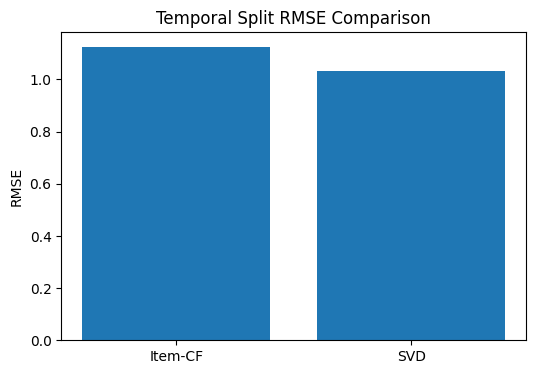

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title(
    "Temporal Split RMSE Comparison"
)

plt.ylabel(
    "RMSE"
)

plt.show()